In [15]:
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW2')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

titanic = pd.read_csv("titanic.csv")
print(titanic.columns.tolist())
print(titanic.shape)

# pclass, sex, age, sibsp and fare
df = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']].copy()
df = df.dropna()
print(df.columns.tolist())

Sex_dummies = pd.get_dummies(df['Sex'], prefix = 'Sex', dtype = int, drop_first = True)
Pclass_dummies = pd.get_dummies(df['Pclass'], prefix='Pclass', dtype=int, drop_first = True)

df = pd.concat([df, Sex_dummies, Pclass_dummies], axis=1)
original_cols = ['Age', 'SibSp', 'Fare']
all_feature_cols = original_cols + Sex_dummies.columns.tolist() + Pclass_dummies.columns.tolist()
print(all_feature_cols)


X = df[all_feature_cols]
y = df[['Survived']]
print(f"X shape:{X.shape}, y shape:{y.shape}")

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
(891, 12)
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']
['Age', 'SibSp', 'Fare', 'Sex_male', 'Pclass_2', 'Pclass_3']
X shape:(714, 6), y shape:(714, 1)


In [16]:
# P4_Q1
X_sm = sm.add_constant(X)

# LogisticRegression
model = sm.Logit(y, X_sm)
result = model.fit()
print(result.summary())
coef_sex = result.params['Sex_male']
ci_sex = result.conf_int().loc['Sex_male']

coef_pclass3 = result.params['Pclass_3']
ci_pclass3 = result.conf_int().loc['Pclass_3']
# params = result.params

# # print(f"\nparams 类型: {type(params)}")
# # print(f"params 值: {params}")

# ci = result.conf_int()
# # print(f"\nconf_int 类型: {type(ci)}")
# # print(f"conf_int 值:\n{ci}")

# coef_sex = params[4]      # Sex_male 的系数
# ci_sex = ci[4]      # Sex_male 的置信区间
# coef_pclass = params[6]   # Pclass_3rd 的系数
# ci_pclass = ci[6]   # Pclass_3rd 的置信区间

print(f"Sex (male) coefficient: {coef_sex:.4f}, 95% CI: [{ci_sex[0]:.4f}, {ci_sex[1]:.4f}]")
print(f"Pclass (3rd) coefficient: {coef_pclass3:.4f}, 95% CI: [{ci_pclass3[0]:.4f}, {ci_pclass3[1]:.4f}]")

Optimization terminated successfully.
         Current function value: 0.445397
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      707
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                  0.3406
Time:                        15:12:58   Log-Likelihood:                -318.01
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 6.378e-68
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1716      0.502      8.306      0.000       3.187       5.156
Age           -0.0441      0.

In [17]:
# P4_Q2

# 定义 Bootstrap 函数，循环1000次
def bootstrap_ci(model, X, y, n_iterations=1000, alpha=0.05):
    coefs = []  # 存储每次Bootstrap的系数
    
    for _ in range(n_iterations):
        # 从训练集中随机抽样（有放回）
        sample = df.sample(frac=1, replace=True)
        X_sample = sample[['Age', 'SibSp', 'Fare', 'Sex_male', 'Pclass_2', 'Pclass_3']]
        X_sample = sm.add_constant(X_sample)
        y_sample = sample['Survived']
        
        model_sample = sm.Logit(y_sample, X_sample)
        result_sample = model_sample.fit(disp=0)
        
        # 获取系数
        coefs.append(result_sample.params)
    
    # 转为DataFrame，便于计算置信区间
    coefs_df = pd.DataFrame(coefs)
    
    # 计算每个系数的95%置信区间
    lower = coefs_df.quantile(alpha/2)
    upper = coefs_df.quantile(1-alpha/2)
    
    return lower, upper

lower, upper = bootstrap_ci(model, X, y)

print("Bootstrap 95% Confidence Intervals:")
print("Sex (male): [{}, {}]".format(lower['Sex_male'], upper['Sex_male']))
print("Pclass (3rd): [{}, {}]".format(lower['Pclass_3'], upper['Pclass_3']))
    

Bootstrap 95% Confidence Intervals:
Sex (male): [-3.065477645075788, -2.2275596792968857]
Pclass (3rd): [-3.295354736373856, -1.87900780569779]



The survival rate divided by sex:
Sex
female    0.754789
male      0.205298
Name: Survived, dtype: float64

The survival rate divided by Pclass:
Pclass
1    0.655914
2    0.479769
3    0.239437
Name: Survived, dtype: float64

The survival rate divided by age (10-year bins)
Age
0.0     0.612903
10.0    0.401961
20.0    0.350000
30.0    0.437126
40.0    0.382022
50.0    0.416667
60.0    0.315789
70.0    0.000000
80.0    1.000000
Name: Survived, dtype: float64


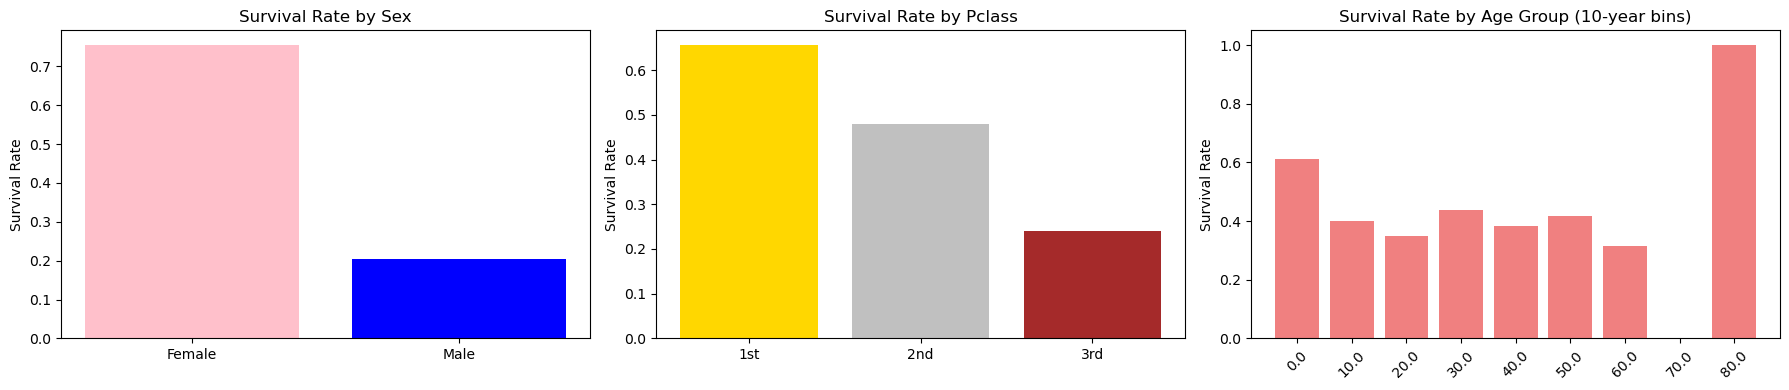

In [18]:
# P4_Q3
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
survival_by_age_group = df.groupby(df['Age'] // 10 * 10)['Survived'].mean() # 按年龄段为10分组

print("\nThe survival rate divided by sex:")
print(survival_by_sex)
print("\nThe survival rate divided by Pclass:")
print(survival_by_pclass)
print("\nThe survival rate divided by age (10-year bins)")
print(survival_by_age_group)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].bar(['Female', 'Male'], survival_by_sex.values, color=['pink', 'blue'])
ax[0].set_title('Survival Rate by Sex')
ax[0].set_ylabel('Survival Rate')
ax[1].bar(['1st', '2nd', '3rd'], survival_by_pclass.values, color=['gold', 'silver', 'brown'])
ax[1].set_title('Survival Rate by Pclass')
ax[1].set_ylabel('Survival Rate')
ax[2].bar(survival_by_age_group.index.astype(str), survival_by_age_group.values, color='lightcoral')
ax[2].set_title('Survival Rate by Age Group (10-year bins)')
ax[2].set_ylabel('Survival Rate')
ax[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# P4_Q4
X_train = df[all_feature_cols].iloc[1:].values
X_train = sm.add_constant(X_train)  # Add constant term
y_train = df[['Survived']].iloc[1:].values

X_test = df[all_feature_cols].iloc[0].values.reshape(1, -1)
X_test = sm.add_constant(X_test, has_constant = 'add')
# print(X_test)
# y_test = df[['Survived']].iloc[0].values
# print(y_test)
# 检查添加常数项后 X_test 的形状
print(f"X_test shape after adding constant: {X_test.shape}")  # 检查形状

# # Fit the logistic regression model
# model_train = sm.Logit(y_train, X_train)
# result_train = model_train.fit(disp=0)

# Check the shapes
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}",)  # Check shapes

def bootstrap_prediction_interval_logit(X_train, y_train, X_test, n_iterations=1000, alpha=0.05):
    predictions = []
    
    for _ in range(n_iterations):
        # 进行有放回的随机抽样
        X_sample, y_sample = resample(X_train, y_train, replace=True)  # 使用 resample 从训练集抽样
        
        # 拟合模型
        model_sample = sm.Logit(y_sample, sm.add_constant(X_sample))  # 使用抽样数据训练模型
        result_sample = model_sample.fit(disp=0)
        
        # 预测测试点
        predictions.append(result_sample.predict(sm.add_constant(X_test))[0])  # 预测测试点的概率
    
    # 计算预测区间
    lower = np.percentile(predictions, alpha/2*100)
    upper = np.percentile(predictions, (1-alpha/2)*100)
    
    return lower, upper

# 获取95%预测区间
lower, upper = bootstrap_prediction_interval_logit(X_train, y_train, X_test)
print(f"Logistic Regression - Bootstrap 95% Prediction Interval for Test Point: [{lower:.4f}, {upper:.4f}]")

X_test shape after adding constant: (1, 7)
X_train shape: (713, 7), X_test shape: (1, 7)
Logistic Regression - Bootstrap 95% Prediction Interval for Test Point: [0.0572, 0.1257]


In [21]:
# P4_Q5

# 对于 QDA 模型，你不需要手动添加截距项。直接使用原始特征数据 X_train 即可
X_train = df[all_feature_cols].iloc[1:].values
y_train = df[['Survived']].iloc[1:].values

X_test = df[all_feature_cols].iloc[0].values.reshape(1, -1)
print(f"X_test shape after adding constant: {X_test.shape}")  # Check the shape

# qda = QuadraticDiscriminantAnalysis()
# qda.fit(X_train, y_train.ravel())  # Fit QDA model

def bootstrap_prediction_interval_qda(X_train, y_train, X_test, n_iterations=1000, alpha=0.05):
    predictions = []
    
    for _ in range(n_iterations):
        X_sample, y_sample = resample(X_train, y_train, replace=True)  # Randomly sample with replacement
        
        qda_sample = QuadraticDiscriminantAnalysis()
        qda_sample.fit(X_sample, y_sample.ravel())  # Fit QDA model to the sample
        
        predictions.append(qda_sample.predict_proba(X_test)[0, 1])
    
    # Compute the prediction interval (lower and upper bounds)
    lower = np.percentile(predictions, alpha/2*100)
    upper = np.percentile(predictions, (1-alpha/2)*100)
    
    return lower, upper

lower_qda, upper_qda = bootstrap_prediction_interval_qda(X_train, y_train, X_test)
print(f"QDA - Bootstrap 95% Prediction Interval for Test Point: [{lower_qda:.4f}, {upper_qda:.4f}]")


X_test shape after adding constant: (1, 6)
QDA - Bootstrap 95% Prediction Interval for Test Point: [0.0172, 0.0727]
